In [1]:
import glob
from os import path
import xarray as xr

def load_hind_fcst_for_debug(year, glorys_dir, fct_dir, month, ensemble, nep_static=None,
                            rename_vars=True):
    """
    Notebook helper: load hindcast + forecast pieces ONLY (no Segment/regridding).

    Hindcast:
      - {glorys_dir}/{year}0101/ocean_month.nc      -> keep time=0 (surface; has zos)
      - {glorys_dir}/{year}0101/ocean_month_z.nc    -> keep time=0 (3D)

    Forecast:
      - {fct_dir}/{year}-{month}-e{ensemble}/history/ocean_month.nc
            -> keep zos only, drop first time (time[1:])
      - {fct_dir}/{year}-{month}-e{ensemble}/history/oceanm_{year}_??.nc
            -> concat monthly files, skip _01 (start Feb), contains 3D vars

    Returns a dict with datasets so you can inspect times, vars, shapes.
    """

    out = {}

    # -------------------------
    # Hindcast (t=0 only)
    # -------------------------
    hind_dir = path.join(glorys_dir, f"{year}0101")

    ds_sfc_hind = xr.open_dataset(path.join(hind_dir, "ocean_month.nc")).isel(time=0, drop=False)
    ds_z_hind   = xr.open_dataset(path.join(hind_dir, "ocean_month_z.nc"))

    # rename vertical dim to z (hindcast uses z_l in your files)
    if "z_l" in ds_z_hind.dims:
        ds_z_hind = ds_z_hind.rename({"z_l": "z"})
    ds_z_hind = ds_z_hind.isel(time=0, drop=False)

    out["ds_sfc_hind"] = ds_sfc_hind
    out["ds_z_hind"]   = ds_z_hind

    # -------------------------
    # Forecast directory
    # -------------------------
    fcst_hist = path.join(fct_dir, f"{year}-{month}-e{ensemble}/history")

    # -------------------------
    # Forecast surface (zos only) from ocean_month.nc (12 months)
    # Drop first time because hindcast provides t=0
    # -------------------------
    ds_sfc_fcst_full = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))
    if "zos" not in ds_sfc_fcst_full.variables:
        raise KeyError(f"'zos' not found in forecast ocean_month.nc: {path.join(fcst_hist, 'ocean_month.nc')}")
    ds_sfc_fcst = ds_sfc_fcst_full[["zos"]].isel(time=slice(1, None))  # <-- drop first time

    out["ds_sfc_fcst_full"] = ds_sfc_fcst_full
    out["ds_sfc_fcst"]      = ds_sfc_fcst

    # -------------------------
    # Forecast 3D monthly files: oceanm_YYYY_MM.nc
    # Skip January file (01), so we start at Feb
    # -------------------------
    fcst_files_3d = sorted(glob.glob(path.join(fcst_hist, f"oceanm_{year}_??.nc")))
    if len(fcst_files_3d) == 0:
        raise FileNotFoundError(f"No forecast 3D monthly files found: {path.join(fcst_hist, f'oceanm_{year}_??.nc')}")
    fcst_files_3d = [f for f in fcst_files_3d if not f.endswith(f"oceanm_{year}_01.nc")]

    if len(fcst_files_3d) == 0:
        raise FileNotFoundError(f"3D monthly files exist but after skipping 01 none left for year={year} in {fcst_hist}")

    ds_z_fcst = xr.open_mfdataset(fcst_files_3d, combine="by_coords")

    # rename vertical dim to z (forecast commonly uses zl)
    if "zl" in ds_z_fcst.dims:
        ds_z_fcst = ds_z_fcst.rename({"zl": "z"})
    if "z_l" in ds_z_fcst.dims:
        ds_z_fcst = ds_z_fcst.rename({"z_l": "z"})

    # optional renaming to match your hindcast conventions
    if rename_vars:
        rename_map = {}
        if "uo" in ds_z_fcst.variables:     rename_map["uo"] = "u"
        if "vo" in ds_z_fcst.variables:     rename_map["vo"] = "v"
        if "thetao" in ds_z_fcst.variables: rename_map["thetao"] = "potT"
        if "so" in ds_z_fcst.variables:     rename_map["so"] = "salt"
        if rename_map:
            ds_z_fcst = ds_z_fcst.rename(rename_map)

    out["fcst_files_3d"] = fcst_files_3d
    out["ds_z_fcst"]     = ds_z_fcst

    # -------------------------
    # Merged products (for quick sanity checks)
    # -------------------------
    ds_sfc_merged = xr.concat([ds_sfc_hind[["zos"]], ds_sfc_fcst], dim="time")
    ds_z_merged   = xr.concat([ds_z_hind, ds_z_fcst], dim="time")

    out["ds_sfc_merged"] = ds_sfc_merged
    out["ds_z_merged"]   = ds_z_merged

    # -------------------------
    # Optional static (lon/lat) if you want later
    # -------------------------
    if nep_static is not None:
        out["st"] = xr.open_dataset(nep_static, decode_times=False)

    return out

In [2]:
year = 2012
glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
fct_dir = "/archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/"
month = "01"
ensemble = "01"

D = load_hind_fcst_for_debug(year, glorys_dir, fct_dir, month, ensemble)

D["ds_sfc_hind"], D["ds_sfc_fcst"], D["ds_sfc_merged"]

/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/3476863866.py:30: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_hind = xr.open_dataset(path.join(hind_dir, "ocean_month.nc")).isel(time=0, drop=False)
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/3476863866.py:31: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_z_hind   = xr.open_dataset(path.join(hind_dir, "ocean_month_z.nc"))
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/3476863866.py:50: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_fcst_full = xr.open_dataset(path.

(<xarray.Dataset> Size: 155MB
 Dimensions:                 (xh: 342, yh: 816, nv: 2, xq: 343, yq: 817, zi: 76)
 Coordinates:
   * xh                      (xh) float64 3kB 229.1 229.2 229.3 ... 254.9 255.0
   * yh                      (yh) float64 7kB 13.86 13.93 14.0 ... 59.52 59.52
     time                    datetime64[ns] 8B 2012-01-16T12:00:00
   * nv                      (nv) float64 16B 1.0 2.0
   * xq                      (xq) float64 3kB 229.1 229.2 229.3 ... 254.9 255.0
   * yq                      (yq) float64 7kB 13.83 13.9 13.96 ... 59.52 59.53
   * zi                      (zi) float64 608B 0.0 2.0 4.0 ... 6.25e+03 6.5e+03
 Data variables: (12/68)
     pbo                     (yh, xh) float32 1MB ...
     zos                     (yh, xh) float32 1MB ...
     ssh                     (yh, xh) float32 1MB ...
     zossq                   (yh, xh) float32 1MB ...
     tos                     (yh, xh) float32 1MB ...
     tossq                   (yh, xh) float32 1MB ...
     ..

In [5]:
D.keys()

dict_keys(['ds_sfc_hind', 'ds_z_hind', 'ds_sfc_fcst_full', 'ds_sfc_fcst', 'fcst_files_3d', 'ds_z_fcst', 'ds_sfc_merged', 'ds_z_merged'])

In [8]:
D["ds_sfc_fcst"]

<xarray.Dataset> Size: 12MB
Dimensions:  (time: 11, yh: 816, xh: 342)
Coordinates:
  * xh       (xh) float64 3kB 229.1 229.2 229.3 229.3 ... 254.8 254.9 255.0
  * yh       (yh) float64 7kB 13.86 13.93 14.0 14.07 ... 59.5 59.51 59.52 59.52
  * time     (time) datetime64[ns] 88B 2012-02-15T12:00:00 ... 2012-12-16T12:...
Data variables:
    zos      (time, yh, xh) float32 12MB ...
Attributes:
    NumFilesInSet:     1
    title:             NEPbgc_fcst_dailyOB01_2012-01-e01
    associated_files:  areacello: 20120101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

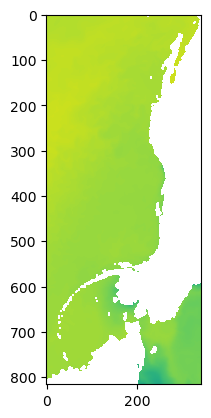

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(np.array(D["ds_z_hind"]['so'][0,:,:]))

In [29]:
print("hind zos time:", D["ds_sfc_hind"]["time"].values)
print("fcst zos time (after drop):", D["ds_sfc_fcst"]["time"].values[:5], "...", D["ds_sfc_fcst"]["time"].values[-1])
print("merged zos time:", D["ds_sfc_merged"]["time"].values[:5], "...", D["ds_sfc_merged"]["time"].values[-1])

print("hind 3D time:", D["ds_z_hind"]["time"].values)
print("fcst 3D time:", D["ds_z_fcst"]["time"].values[:5], "...", D["ds_z_fcst"]["time"].values[-1])
print("merged 3D time:", D["ds_z_merged"]["time"].values[:5], "...", D["ds_z_merged"]["time"].values[-1])

hind zos time: 2012-01-16T12:00:00.000000000
fcst zos time (after drop): ['2012-02-15T12:00:00.000000000' '2012-03-16T12:00:00.000000000'
 '2012-04-16T00:00:00.000000000' '2012-05-16T12:00:00.000000000'
 '2012-06-16T00:00:00.000000000'] ... 2012-12-16T12:00:00.000000000
merged zos time: ['2012-01-16T12:00:00.000000000' '2012-02-15T12:00:00.000000000'
 '2012-03-16T12:00:00.000000000' '2012-04-16T00:00:00.000000000'
 '2012-05-16T12:00:00.000000000'] ... 2012-12-16T12:00:00.000000000
hind 3D time: 2012-01-16T12:00:00.000000000
fcst 3D time: ['2012-02-15T12:00:00.000000000' '2012-03-16T12:00:00.000000000'
 '2012-04-16T00:00:00.000000000' '2012-05-16T12:00:00.000000000'
 '2012-06-16T00:00:00.000000000'] ... 2012-12-16T12:00:00.000000000
merged 3D time: ['2012-01-16T12:00:00.000000000' '2012-02-15T12:00:00.000000000'
 '2012-03-16T12:00:00.000000000' '2012-04-16T00:00:00.000000000'
 '2012-05-16T12:00:00.000000000'] ... 2012-12-16T12:00:00.000000000


In [56]:
def std_tracer(ds, var, xname="xh", yname="yh"):
    """
    Force ds[var] to have dims (time, z, yh, xh) with consistent dim names.
    """
    if var not in ds:
        return ds

    da = ds[var]

    # --- rename vertical dim to z ---
    if "zl" in da.dims:
        da = da.rename({"zl": "z"})
    if "z_l" in da.dims:
        da = da.rename({"z_l": "z"})

    # --- rename horizontal dims if they use different names ---
    # common alternates: (xt_ocean, yt_ocean) or (xh, yh) already
    ren = {}
    for d in da.dims:
        if d.lower() in ["yt_ocean", "yh", "y", "j"] and d != yname and d != "time" and d != "z":
            # only rename if size matches ds sizes (safer to do by size check outside if needed)
            pass
    # Do explicit known renames only (safer):
    if "yt_ocean" in da.dims: ren["yt_ocean"] = yname
    if "xt_ocean" in da.dims: ren["xt_ocean"] = xname
    if "xh" in da.dims and xname != "xh": ren["xh"] = xname
    if "yh" in da.dims and yname != "yh": ren["yh"] = yname
    if ren:
        da = da.rename(ren)

    # --- ensure time dim exists ---
    if "time" not in da.dims:
        da = da.expand_dims(time=[0])

    # --- transpose to canonical order if possible ---
    needed = ("time", "z", yname, xname)
    if all(d in da.dims for d in needed):
        da = da.transpose(*needed)

    ds[var] = da
    return ds


def std_uv(ds):
    """
    Force uo to (time,z,yh,xq) and vo to (time,z,yq,xh) if present.
    """
    if "uo" in ds:
        da = ds["uo"]
        if "zl" in da.dims: da = da.rename({"zl":"z"})
        if "z_l" in da.dims: da = da.rename({"z_l":"z"})
        if "time" not in da.dims: da = da.expand_dims(time=[0])
        # common u dims: (time,z,yh,xq)
        if all(d in da.dims for d in ("time","z","yh","xq")):
            da = da.transpose("time","z","yh","xq")
        ds["uo"] = da

    if "vo" in ds:
        da = ds["vo"]
        if "zl" in da.dims: da = da.rename({"zl":"z"})
        if "z_l" in da.dims: da = da.rename({"z_l":"z"})
        if "time" not in da.dims: da = da.expand_dims(time=[0])
        # common v dims: (time,z,yq,xh)
        if all(d in da.dims for d in ("time","z","yq","xh")):
            da = da.transpose("time","z","yq","xh")
        ds["vo"] = da

    return ds

In [68]:
import xarray as xr
from os import path

# --------- EDIT THESE ----------
year = 2012
month = "01"
ensemble = "01"

glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
rst_dir    = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/restart/"
fct_dir    = "/archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/"
# -------------------------------

# ==========================
# Hindcast (t=0 only)  --- RESTART
# ==========================
ds_z_hind = xr.open_dataset(
    path.join(rst_dir, f"restdate_{year}{month}01/MOM_{year}{month}01.res.nc"),
    decode_cf=False
)

# keep first record
ds_z_hind = ds_z_hind.isel(Time=0, drop=False)

# rename Time dim -> time (so concat uses same dim)
if "Time" in ds_z_hind.dims:
    ds_z_hind = ds_z_hind.rename({"Time": "time"})

# rename vertical dim if present
if "zl" in ds_z_hind.dims:
    ds_z_hind = ds_z_hind.rename({"zl": "z"})

# IMPORTANT: rename vars (ASSIGN BACK!)
ds_z_hind = ds_z_hind.rename({'Salt': 'so', 'Temp': 'thetao', 'u': 'uo', 'v': 'vo'})

# IMPORTANT: rename restart dims to match forecast (this fixes the PiB broadcast)
# Your restart currently uses: (time, Layer, lath, lonh)
rename_dims = {}
if "Layer" in ds_z_hind.dims: rename_dims["Layer"] = "z"
if "lath"  in ds_z_hind.dims: rename_dims["lath"]  = "yh"
if "lonh"  in ds_z_hind.dims: rename_dims["lonh"]  = "xh"
# (only if present; won't hurt if missing)
if "lonq"  in ds_z_hind.dims: rename_dims["lonq"]  = "xq"
if "latq"  in ds_z_hind.dims: rename_dims["latq"]  = "yq"
if rename_dims:
    ds_z_hind = ds_z_hind.rename(rename_dims)

# optional but safe: put tracer dims in the same order as forecast
if "so" in ds_z_hind and all(d in ds_z_hind["so"].dims for d in ("time","z","yh","xh")):
    ds_z_hind["so"] = ds_z_hind["so"].transpose("time","z","yh","xh")
if "thetao" in ds_z_hind and all(d in ds_z_hind["thetao"].dims for d in ("time","z","yh","xh")):
    ds_z_hind["thetao"] = ds_z_hind["thetao"].transpose("time","z","yh","xh")

# ==========================
# Hindcast zos (t=0)
# ==========================
ds_sfc_hind = xr.open_dataset(path.join(glorys_dir, f"{year}0101/ocean_month.nc"))
ds_sfc_hind = ds_sfc_hind.isel(time=0, drop=False)

print("hind so :", ds_z_hind["so"].shape if "so" in ds_z_hind else "NO so")
print("hind uo :", ds_z_hind["uo"].shape if "uo" in ds_z_hind else "NO uo")
print("hind zos:", ds_sfc_hind["zos"].shape if "zos" in ds_sfc_hind else "NO zos")
print("hind so dims:", ds_z_hind["so"].dims if "so" in ds_z_hind else "NO so")

# ==========================
# Forecast dirs
# ==========================
fcst_hist = path.join(fct_dir, f"{year}-{month}-e{ensemble}/history")

# ==========================
# Forecast zos from ocean_month.nc (drop first time)
# ==========================
ds_sfc_fcst = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))[["zos"]]

da = ds_sfc_fcst["zos"]
if "time" in da.dims and da.dims[0] != "time":
    new_order = ("time",) + tuple(d for d in da.dims if d != "time")
    ds_sfc_fcst["zos"] = da.transpose(*new_order)

ds_sfc_fcst = ds_sfc_fcst.isel(time=slice(1, None))
print("forecast zos:", ds_sfc_fcst["zos"].shape)

# ==========================
# Forecast 3D: open month-by-month oceanm_YYYY_MM.nc
# ==========================
liste_files = [
    f"oceanm_{year}_02.nc", f"oceanm_{year}_03.nc", f"oceanm_{year}_04.nc", f"oceanm_{year}_05.nc",
    f"oceanm_{year}_06.nc", f"oceanm_{year}_07.nc", f"oceanm_{year}_08.nc", f"oceanm_{year}_09.nc",
    f"oceanm_{year}_10.nc", f"oceanm_{year}_11.nc", f"oceanm_{year}_12.nc",
]

ds_list = []
for file in liste_files:
    fp = path.join(fcst_hist, file)
    print("opening:", fp)

    tmp_z = xr.open_dataset(fp)

    # rename forecast vars -> hindcast vars (only if present)
    rename_vars = {}
    if "salt" in tmp_z: rename_vars["salt"] = "so"
    if "potT" in tmp_z: rename_vars["potT"] = "thetao"
    if "u"    in tmp_z: rename_vars["u"]    = "uo"
    if "v"    in tmp_z: rename_vars["v"]    = "vo"
    if rename_vars:
        tmp_z = tmp_z.rename(rename_vars)

    # rename vertical dim -> z
    if "zl" in tmp_z.dims:
        tmp_z = tmp_z.rename({"zl": "z"})
    if "z_l" in tmp_z.dims:
        tmp_z = tmp_z.rename({"z_l": "z"})

    ds_list.append(tmp_z[["so","thetao","uo","vo"]])

ds_z_fct = xr.concat(ds_list, dim="time")
print("forecast so :", ds_z_fct["so"].shape if "so" in ds_z_fct else "NO so")
print("forecast uo :", ds_z_fct["uo"].shape if "uo" in ds_z_fct else "NO uo")
print("forecast so dims:", ds_z_fct["so"].dims if "so" in ds_z_fct else "NO so")

# ==========================
# Merge (should NOT explode now)
# ==========================
ds_z_hind = ds_z_hind[["so","thetao","uo","vo"]]
ds_z_fct  = ds_z_fct[["so","thetao","uo","vo"]]

print("HIND so dims:", ds_z_hind["so"].dims, ds_z_hind["so"].shape)
print("FCT  so dims:", ds_z_fct["so"].dims,  ds_z_fct["so"].shape)

ds_z = xr.concat([ds_z_hind, ds_z_fct], dim="time", join="exact")

ds_sfc = xr.concat([ds_sfc_hind[["zos"]], ds_sfc_fcst[["zos"]]], dim="time")

print("\nMERGED zos:", ds_sfc["zos"].shape)
print("MERGED so :", ds_z["so"].shape)
print("MERGED uo :", ds_z["uo"].shape)

print("so frac NaN for time>=1:", float(ds_z["so"].isel(time=slice(1, None)).isnull().mean()))

/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:57: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_hind = xr.open_dataset(path.join(glorys_dir, f"{year}0101/ocean_month.nc"))
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_fcst = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))[["zos"]]
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:97: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(fp)
/vftmp/Remi.Pag

hind so : (75, 816, 342)
hind uo : (75, 816, 343)
hind zos: (816, 342)
hind so dims: ('z', 'yh', 'xh')
forecast zos: (11, 816, 342)
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_02.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_03.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_04.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_05.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_06.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_07.nc


/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:97: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(fp)
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:97: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(fp)
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:97: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(fp)
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/2826280663.py:97: FutureWarning: In a future version of xarray decode_time

opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_08.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_09.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_10.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_11.nc
opening: /archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/2012-01-e01/history/oceanm_2012_12.nc
forecast so : (11, 75, 816, 342)
forecast uo : (11, 75, 816, 343)
forecast so dims: ('time', 'z', 'yh', 'xh')
HIND so dims: ('z', 'yh', 'xh') (75, 816, 342)
FCT  so dims: ('time', 'z', 'yh', 'xh') (11, 75, 816, 342)


ValueError: coordinate 'time' not present in all datasets.

In [99]:


# -------------------------
# EDIT THESE
# -------------------------
year0  = 2012
month0 = 1        # start month
nt     = 12       # number of monthly records (t0 + 11 forecast months)
# -------------------------

# -------------------------
# DIMENSION SIZES (edit if needed)
# -------------------------
nz = 75
ny = 816
nx = 342
nxq = 343
nyq = 817
nzi = 76
nnv = 2

# -------------------------
# BUILD CF TIME + BOUNDS
# -------------------------
ref = pd.Timestamp(year=year0, month=month0, day=1)

# month starts for nt months
month_starts = pd.date_range(ref, periods=nt, freq="MS")
next_starts  = pd.date_range(ref + pd.offsets.MonthBegin(1), periods=nt, freq="MS")

# numeric time: days since ref
time_days = ((month_starts - ref) / np.timedelta64(1, "D")).astype("float64")

# time bounds: [start, next_start] in same units
b0 = ((month_starts - ref) / np.timedelta64(1, "D")).astype("float64")
b1 = ((next_starts  - ref) / np.timedelta64(1, "D")).astype("float64")
time_bnds = np.stack([b0, b1], axis=1)  # (time, nv)

# -------------------------
# COORDINATES
# -------------------------
coords = dict(
    time=("time", time_days),
    nv=("nv", np.arange(nnv)),
    z=("z", np.arange(nz)),
    zi=("zi", np.arange(nzi)),
    yh=("yh", np.arange(ny)),
    xh=("xh", np.arange(nx)),
    yq=("yq", np.arange(nyq)),
    xq=("xq", np.arange(nxq)),
)

# -------------------------
# EMPTY DATASET (fill later)
# -------------------------
ds = xr.Dataset(
    data_vars=dict(
        time_bnds=(("time", "nv"), time_bnds),

        # examples of empty vars you can fill later
        zos    =(("time","yh","xh"), np.zeros((nt, ny, nx))),
        so     =(("time","z","yh","xh"), np.zeros((nt, nz, ny, nx))),
        thetao =(("time","z","yh","xh"), np.zeros((nt, nz, ny, nx))),
        uo     =(("time","z","yh","xq"), np.zeros((nt, nz, ny, nxq))),
        vo     =(("time","z","yq","xh"), np.zeros((nt, nz, nyq, nx))),
    ),
    coords=coords
)

# -------------------------
# TIME ATTRIBUTES (CF-style)
# -------------------------
ds["time"].attrs = {
    "units": f"days since {year0:04d}-{month0:02d}-01 00:00:00",
    "long_name": "time",
    "axis": "T",
    "calendar_type": "GREGORIAN",
    "calendar": "gregorian",
    "bounds": "time_bnds",
}

ds["time_bnds"].attrs = {"long_name": "time bounds"}

print(ds)
print("time:", ds["time"].values[:5], "...", ds["time"].values[-1])
print("time_bnds first:", ds["time_bnds"].isel(time=0).values)
print("time_bnds last :", ds["time_bnds"].isel(time=-1).values)

<xarray.Dataset> Size: 8GB
Dimensions:    (time: 12, nv: 2, yh: 816, xh: 342, z: 75, xq: 343, yq: 817,
                zi: 76)
Coordinates:
  * time       (time) float64 96B 0.0 31.0 60.0 91.0 ... 244.0 274.0 305.0 335.0
  * nv         (nv) int64 16B 0 1
  * z          (z) int64 600B 0 1 2 3 4 5 6 7 8 9 ... 66 67 68 69 70 71 72 73 74
  * zi         (zi) int64 608B 0 1 2 3 4 5 6 7 8 ... 67 68 69 70 71 72 73 74 75
  * yh         (yh) int64 7kB 0 1 2 3 4 5 6 7 ... 809 810 811 812 813 814 815
  * xh         (xh) int64 3kB 0 1 2 3 4 5 6 7 ... 335 336 337 338 339 340 341
  * yq         (yq) int64 7kB 0 1 2 3 4 5 6 7 ... 810 811 812 813 814 815 816
  * xq         (xq) int64 3kB 0 1 2 3 4 5 6 7 ... 336 337 338 339 340 341 342
Data variables:
    time_bnds  (time, nv) float64 192B 0.0 31.0 31.0 60.0 ... 335.0 335.0 366.0
    zos        (time, yh, xh) float64 27MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    so         (time, z, yh, xh) float64 2GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    thetao     (

In [135]:
import xarray as xr
import numpy as np
import pandas as pd
from os import path




# -------------------------
# EDIT THESE
# -------------------------
year0  = 2012
month0 = 1        # start month
nt     = 12       # number of monthly records (t0 + 11 forecast months)
# -------------------------

# -------------------------
# DIMENSION SIZES (edit if needed)
# -------------------------
nz = 75
ny = 816
nx = 342
nxq = 343
nyq = 817
nzi = 76
nnv = 2

# -------------------------
# BUILD CF TIME + BOUNDS
# -------------------------
ref = pd.Timestamp(year=year0, month=month0, day=1)

# month starts for nt months
month_starts = pd.date_range(ref, periods=nt, freq="MS")
next_starts  = pd.date_range(ref + pd.offsets.MonthBegin(1), periods=nt, freq="MS")

# numeric time: days since ref
time_days = ((month_starts - ref) / np.timedelta64(1, "D")).astype("float64")

# time bounds: [start, next_start] in same units
b0 = ((month_starts - ref) / np.timedelta64(1, "D")).astype("float64")
b1 = ((next_starts  - ref) / np.timedelta64(1, "D")).astype("float64")
time_bnds = np.stack([b0, b1], axis=1)  # (time, nv)

# -------------------------
# COORDINATES
# -------------------------
coords = dict(
    time=("time", time_days),
    nv=("nv", np.arange(nnv)),
    z=("z", np.arange(nz)),
    zi=("zi", np.arange(nzi)),
    yh=("yh", np.arange(ny)),
    xh=("xh", np.arange(nx)),
    yq=("yq", np.arange(nyq)),
    xq=("xq", np.arange(nxq)),
)

# -------------------------
# EMPTY DATASET (fill later)
# -------------------------
ds = xr.Dataset(
    data_vars=dict(
        time_bnds=(("time", "nv"), time_bnds),

        # examples of empty vars you can fill later
        zos    =(("time","yh","xh"), np.zeros((nt, ny, nx))),
        so     =(("time","z","yh","xh"), np.zeros((nt, nz, ny, nx))),
        thetao =(("time","z","yh","xh"), np.zeros((nt, nz, ny, nx))),
        uo     =(("time","z","yh","xq"), np.zeros((nt, nz, ny, nxq))),
        vo     =(("time","z","yq","xh"), np.zeros((nt, nz, nyq, nx))),
    ),
    coords=coords
)

# -------------------------
# TIME ATTRIBUTES (CF-style)
# -------------------------
ds["time"].attrs = {
    "units": f"days since {year0:04d}-{month0:02d}-01 00:00:00",
    "long_name": "time",
    "axis": "T",
    "calendar_type": "GREGORIAN",
    "calendar": "gregorian",
    "bounds": "time_bnds",
}

ds["time_bnds"].attrs = {"long_name": "time bounds"}

print(ds)
print("time:", ds["time"].values[:5], "...", ds["time"].values[-1])
print("time_bnds first:", ds["time_bnds"].isel(time=0).values)
print("time_bnds last :", ds["time_bnds"].isel(time=-1).values)


# --------- EDIT THESE ----------
year = 2012
month = "01"
ensemble = "01"

glorys_dir = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/history/"
rst_dir    = "/archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_hindcast02/restart/"
fct_dir    = "/archive/Remi.Pages/forecast_goa/NEPbgc_fcst_dailyOB01/"
# -------------------------------

# ==========================
# Hindcast (t=0 only)  --- RESTART
# ==========================
ds_z_hind = xr.open_dataset(
    path.join(rst_dir, f"restdate_{year}{month}01/MOM_{year}{month}01.res.nc"),
    decode_cf=False)


# IMPORTANT: rename vars (ASSIGN BACK!)
ds_z_hind = ds_z_hind.rename({'Salt': 'so', 'Temp': 'thetao', 'u': 'uo', 'v': 'vo'})

# FIll the new dataset 
ds['so'][0,:,:,:] = np.array(ds_z_hind['so'][0,:,:,:])
ds['thetao'][0,:,:,:] = np.array(ds_z_hind['thetao'][0,:,:,:])
ds['uo'][0,:,:,:] = np.array(ds_z_hind['uo'][0,:,:,:])
ds['vo'][0,:,:,:] = np.array(ds_z_hind['vo'][0,:,:,:])



# ==========================
# Hindcast zos (t=0)
# ==========================
ds_sfc_hind = xr.open_dataset(path.join(glorys_dir, f"{year}0101/ocean_month.nc"))
ds['zos'][0,:,:] = np.array(ds_sfc_hind['zos'][0,:,:])
# Remove bad value 
ds["uo"][0] = ds["uo"][0].where(ds["uo"][0] <= 1e10, np.nan)
ds["vo"][0] = ds["vo"][0].where(ds["vo"][0] <= 1e10, np.nan)



# Now go for the fcst 

# ==========================================================
# --- Forecast directories
# ==========================================================
fcst_hist = path.join(fct_dir, f"{year}-{month}-e{ensemble}/history")
# ==========================================================
# --- Forecast SURFACE (zos) from ocean_month.nc (12 months)
# Drop first forecast time because hindcast already provides t=0
# ==========================================================
ds_sfc_fcst = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))
ds_sfc_fcst = ds_sfc_fcst.isel(time=slice(1, None))

liste_files=[ 'oceanm_2012_02.nc',  'oceanm_2012_03.nc', 'oceanm_2012_04.nc', 'oceanm_2012_05.nc' , 'oceanm_2012_06.nc',
'oceanm_2012_07.nc',  'oceanm_2012_08.nc' , 'oceanm_2012_09.nc' , 'oceanm_2012_10.nc' , 'oceanm_2012_11.nc',  'oceanm_2012_12.nc']
for file in liste_files:
    print(file)
    tmp_z = xr.open_dataset(path.join(fcst_hist, file))
    tmp_z = tmp_z.rename_vars({'salt': 'so','potT': 'thetao','u': 'uo','v': 'vo'})
    ds['so'][1:12,:,:,:] = np.array(tmp_z['so'][0,:,:,:])
    ds['thetao'][1:12,:,:,:] = np.array(tmp_z['thetao'][0,:,:,:])
    ds['uo'][1:12,:,:,:] = np.array(tmp_z['uo'][0,:,:,:])
    ds['vo'][1:12,:,:,:] = np.array(tmp_z['vo'][0,:,:,:])
    

ds["uo"] = ds["uo"].where(ds["uo"] <= 1e10, np.nan)
ds["vo"] = ds["vo"].where(ds["vo"] <= 1e10, np.nan)

ds_sfc_fcst_full = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))
ds_sfc_fcst = ds_sfc_fcst_full[["zos"]].isel(time=slice(1, None))  # <-- drop first time

ds['zos'][1:12,:,:] = np.array(ds_sfc_fcst['zos'][0,:,:])


ds["vo"][0] = ds["vo"][0].where(~ds["vo"].isel(time=8).isnull())
ds["uo"][0] = ds["uo"][0].where(~ds["uo"].isel(time=8).isnull())
ds["zos"][0] = ds["zos"][0].where(~ds["zos"].isel(time=8).isnull())
ds["thetao"][0] = ds["thetao"][0].where(~ds["thetao"].isel(time=8).isnull())
ds["so"][0] = ds["so"][0].where(~ds["so"].isel(time=8).isnull())

/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:36: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_hind = xr.open_dataset(path.join(glorys_dir, f"{year}0101/ocean_month.nc"))
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:54: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_fcst = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:61: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(path.join(fcst_hist, file))


oceanm_2012_02.nc
oceanm_2012_03.nc


/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:61: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(path.join(fcst_hist, file))


oceanm_2012_04.nc


/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:61: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(path.join(fcst_hist, file))


...

/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:61: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(path.join(fcst_hist, file))


oceanm_2012_11.nc


/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:61: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(path.join(fcst_hist, file))


oceanm_2012_12.nc


/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:61: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tmp_z = xr.open_dataset(path.join(fcst_hist, file))
/vftmp/Remi.Pages/pid3824364/ipykernel_3849645/940303753.py:72: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_sfc_fcst_full = xr.open_dataset(path.join(fcst_hist, "ocean_month.nc"))


In [126]:
ds['uo']

<xarray.DataArray 'uo' (time: 12, z: 75, yh: 816, xq: 343)> Size: 2GB
array([[[[ 8.77238942e-02,  5.30732353e-02,  7.10082280e-02, ...,
           0.00000000e+00,  0.00000000e+00, -5.48879584e-07],
         [ 7.36917366e-02,  3.26255872e-02,  4.09937350e-02, ...,
           0.00000000e+00,  0.00000000e+00, -5.48879584e-07],
         [ 2.17041488e-02, -1.67829635e-02, -1.38157454e-02, ...,
           0.00000000e+00,  0.00000000e+00, -5.48879584e-07],
         ...,
         [            nan,  0.00000000e+00,  0.00000000e+00, ...,
          -8.24065621e-03, -9.33650782e-03, -9.73026280e-03],
         [            nan,  0.00000000e+00,  0.00000000e+00, ...,
          -1.15377101e-02, -1.17080767e-02, -1.18379361e-02],
         [            nan,  0.00000000e+00,  0.00000000e+00, ...,
          -1.54594660e-02, -1.61472843e-02, -1.40097828e-02]],

        [[ 8.85340416e-02,  7.36168356e-02,  8.94558884e-02, ...,
           0.00000000e+00,  0.00000000e+00, -5.48879584e-07],
         [ 7.45147164e-02,  5.29475876e-02,  5.91701418e-02, ...,
           0.00000000e+00,  0.00000000e+00, -5.48879584e-07],
         [ 2.22264348e-02,  3.29043447e-03,  4.24811267e-03, ...,
           0.00000000e+00,  0.00000000e+00, -5.48879584e-07],
...
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]]])
Coordinates:
  * time     (time) float64 96B 0.0 31.0 60.0 91.0 ... 244.0 274.0 305.0 335.0
  * z        (z) int64 600B 0 1 2 3 4 5 6 7 8 9 ... 66 67 68 69 70 71 72 73 74
  * yh       (yh) int64 7kB 0 1 2 3 4 5 6 7 ... 808 809 810 811 812 813 814 815
  * xq       (xq) int64 3kB 0 1 2 3 4 5 6 7 ... 335 336 337 338 339 340 341 342

In [131]:
ds["vo"][0] = ds["vo"][0].where(~ds["vo"].isel(time=8).isnull())

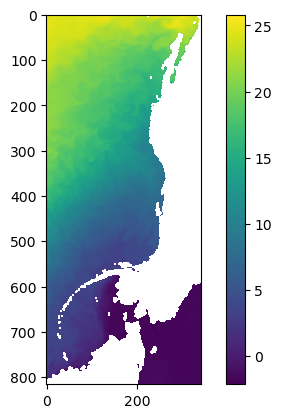

In [137]:
plt.imshow(ds['thetao'][0,0,:,:] );plt.colorbar()

In [110]:
ds['zos'][0,:,:]

<xarray.DataArray 'zos' (yh: 816, xh: 342)> Size: 2MB
array([[ 0.04386959,  0.04581884,  0.04782546, ...,         nan,
                nan,         nan],
       [ 0.04547165,  0.04745164,  0.04949406, ...,         nan,
                nan,         nan],
       [ 0.04737745,  0.0493845 ,  0.05145456, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ..., -0.46190822,
        -0.46104705, -0.45856193],
       [        nan,         nan,         nan, ..., -0.46131793,
        -0.46031272, -0.45781612],
       [        nan,         nan,         nan, ..., -0.46023861,
        -0.45935506, -0.45703527]])
Coordinates:
    time     float64 8B 0.0
  * yh       (yh) int64 7kB 0 1 2 3 4 5 6 7 ... 808 809 810 811 812 813 814 815
  * xh       (xh) int64 3kB 0 1 2 3 4 5 6 7 ... 334 335 336 337 338 339 340 341

In [62]:
ds_z_hind.keys()

KeysView(<xarray.Dataset> Size: 4GB
Dimensions:          (lath: 816, lonh: 342, latq: 817, lonq: 343, Layer: 75)
Coordinates:
  * lath             (lath) float64 7kB 13.86 13.93 14.0 ... 59.51 59.52 59.52
  * lonh             (lonh) float64 3kB 229.1 229.2 229.3 ... 254.8 254.9 255.0
  * latq             (latq) float64 7kB 13.83 13.9 13.96 ... 59.51 59.52 59.53
  * lonq             (lonq) float64 3kB 229.1 229.2 229.3 ... 254.8 254.9 255.0
  * Layer            (Layer) float64 600B 1.0 3.0 5.0 ... 6.125e+03 6.375e+03
    Time             float64 8B 7.345e+05
Data variables: (12/33)
    Temp             (Layer, lath, lonh) float64 167MB ...
    Salt             (Layer, lath, lonh) float64 167MB ...
    h                (Layer, lath, lonh) float64 167MB ...
    u                (Layer, lath, lonq) float64 168MB ...
    v                (Layer, latq, lonh) float64 168MB ...
    frazil           (lath, lonh) float64 2MB ...
    ...               ...
    irr_aclm_z       (Layer, lath, lonh) 